En este caso se muestra la visualizacion de los datos que podemos observar que hay dos circulos  con esto rompe nuestro modelo anterior que es trazar linea recta para separar los datos en calificacion pero en un circulo cambia ya que al moiimneot der trasar la linea sera imposible hacer la separacion y recordemos que nuestro campo es un campo lineal 

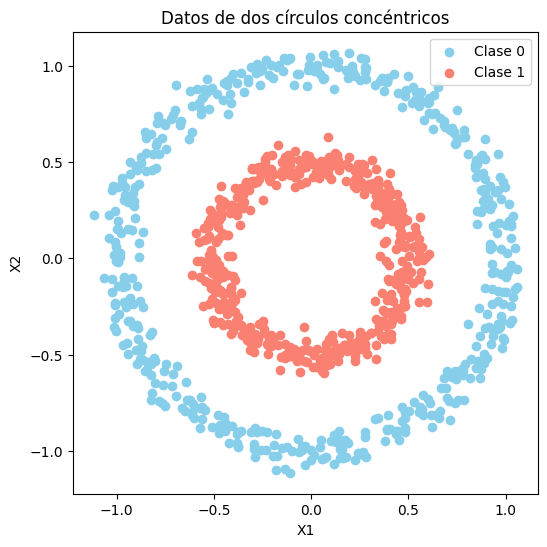

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

np.random.seed(42)

X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

plt.figure(figsize=(6, 6))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

con esto se hace el ejemplo de una sola capa que sera tambien su capa de salida dando funcion de activacion Sigmoid con esto se hace dos variables ya que encuentra esta neurona como tambien de salida 
Imagínalo como un mapa:
```
        X2
        |
    *   |   *
  *   * | *   *
--------+--------  X1
  *   * | *   *
    *   |   *
        |
Tambien de caracteritica de este entyrenamiento se encuentra bde optimizador a Adam ya que se encuentra el mas establke para este modelo,, en el .fit se encuentra un entrenamiento de 100 epochs para su experimento

Alfinal del experimento se encuentra un Accuracy DEL 50% 

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

modelo_simple = Sequential([
    Dense(1, activation='sigmoid', input_shape=(2,))
])

modelo_simple.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

modelo_simple.fit(X, Y, epochs=100, verbose=0)

perdida, accuracy = modelo_simple.evaluate(X, Y)
print(f"Modelo Simple - Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4818 - loss: 0.6934  
Modelo Simple - Accuracy: 0.4990


En este caso de modelo se hacer una profundizacion de neurona de tres capas con funcion de activacion relu dando sus primeras dos capas de 16 Neuronas y su ultima capa de 8 neuronas con esto su neurona de salida tiene la activacion sigmoid para que haga la prediccion

Con esto tambien se hace el entrenamiento en igual de timepo que son 100 epochs con esto nos asegura un acurracy del 100%

In [3]:
modelo_profundo = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

modelo_profundo.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

modelo_profundo.fit(X, Y, epochs=100, verbose=0)

perdida, accuracy = modelo_profundo.evaluate(X, Y)
print(f"Modelo Profundo - Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 8.1770e-05
Modelo Profundo - Accuracy: 1.0000


## Conclusiones

En este taller trabajamos con datos de dos características (X1, X2), 
lo que nos permite ubicar cada punto en un plano de dos dimensiones.

El problema de los círculos concéntricos es un ejemplo clásico de un 
problema **no linealmente separable**, es decir, que no puede resolverse 
trazando una simple línea recta. Esto quedó demostrado con el 
**modelo simple** (1 sola capa), el cual apenas alcanzó un accuracy 
cercano al 50%, equivalente a adivinar al azar.

Para resolver este tipo de problemas se necesitan **redes neuronales 
profundas**, que son modelos con múltiples capas ocultas. Cada capa 
con activación ReLU transforma y "dobla" el espacio de los datos, 
haciendo que un problema que antes no era separable, ahora sí lo sea.

El **modelo profundo** (3 capas ocultas) logró un accuracy cercano al 
99%, logrando aprender la forma circular de los datos correctamente.

Una conclusión importante es que no existe un número fijo de capas o 
neuronas que funcione para todos los problemas — el accuracy es 
precisamente la métrica que nos guía para saber si nuestro modelo 
tiene suficiente profundidad para aprender el patrón.

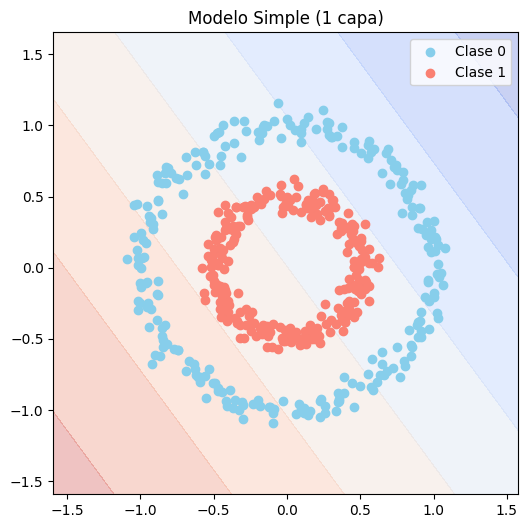

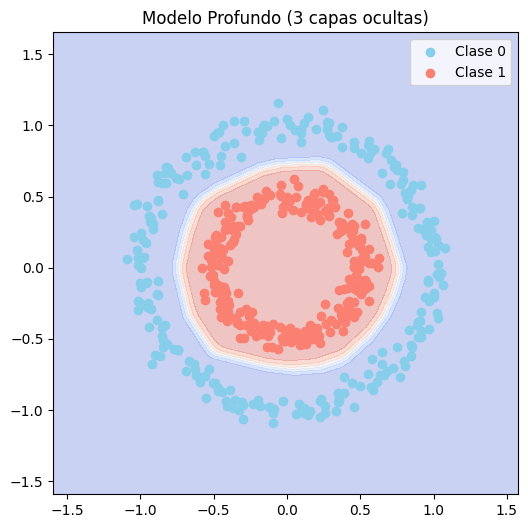

In [4]:
def plot_decision_boundary(modelo, X, Y, titulo):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon",  label="Clase 1")
    plt.title(titulo)
    plt.legend()
    plt.show()

plot_decision_boundary(modelo_simple,   X, Y, "Modelo Simple (1 capa)")
plot_decision_boundary(modelo_profundo, X, Y, "Modelo Profundo (3 capas ocultas)")